# BigMart Sales Data Analysis

## Objective
The objective of this project is to analyze the BigMart sales dataset and identify the factors affecting product sales across different outlets.

This analysis includes:
- Data cleaning
- Missing value treatment
- Exploratory Data Analysis (EDA)
- Visualization
- Feature relationship analysis

# Importing Required Libraries

The following libraries are used for:
- NumPy → Numerical computations
- Pandas → Data manipulation
- Matplotlib & Seaborn → Data visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bs_data = pd.read_csv(r"C:\Users\harsh kasana\Downloads\big_mart_sales.csv")

# Dataset Preview

Displaying the first and last few rows of the dataset to understand its structure and features.

In [3]:
bs_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
bs_data.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [5]:
bs_data.shape

(8523, 12)

## Observation
- The dataset contains 8523 rows and 12 columns.
- The dataset is suitable for performing machine learning and exploratory data analysis.

In [6]:
bs_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Observation
- The dataset contains both numerical and categorical columns.
- Missing values are present in:
  - Item_Weight
  - Outlet_Size
- Most columns have appropriate data types.

In [7]:
bs_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Observation
- Numerical features show variation in scale and distribution.
- Item_MRP has a wide range of values.
- Some columns may contain outliers due to high maximum values.

In [8]:
bs_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [9]:
bs_data.duplicated().sum()

np.int64(0)

# Missing Value Treatment

Handling missing values is important to improve data quality and model performance.

In [10]:
bs_data["Item_Weight"].fillna(bs_data["Item_Weight"].mean(),inplace=True)

C:\Users\harsh kasana\AppData\Local\Temp\ipykernel_6328\3804398895.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bs_data["Item_Weight"].fillna(bs_data["Item_Weight"].mean(),inplace=True)


In [14]:
bs_data["Outlet_Size"].fillna(bs_data["Outlet_Size"].mode()[0],inplace=True)

C:\Users\harsh kasana\AppData\Local\Temp\ipykernel_6328\1819092782.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bs_data["Outlet_Size"].fillna(bs_data["Outlet_Size"].mode()[0],inplace=True)


## Observation
- Missing values in Item_Weight were replaced using mean values.
- Missing values in Outlet_Size were replaced using mode values.
- Dataset is now free from null values.

# Univariate Analysis

Analyzing individual numerical and categorical features to understand their distribution and frequency.

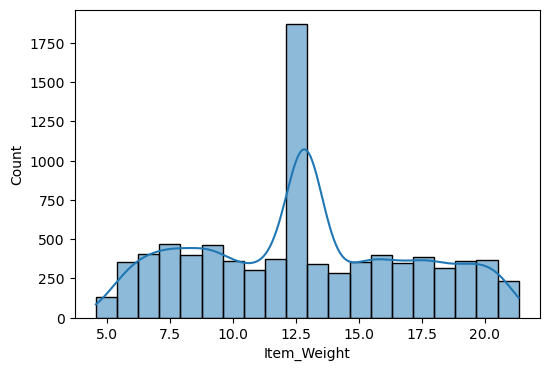

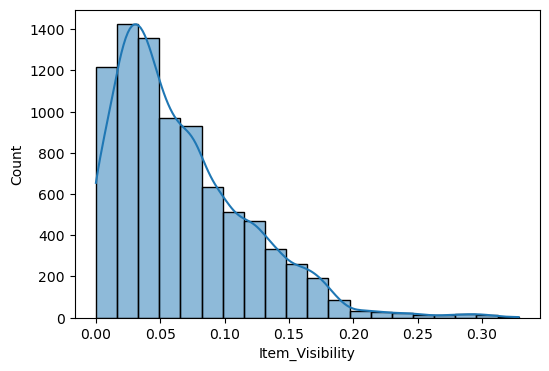

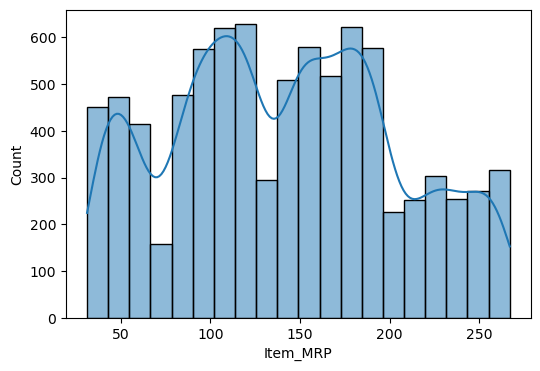

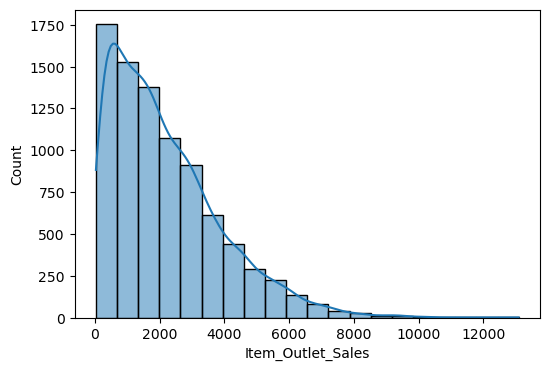

In [18]:
num_cols =["Item_Weight","Item_Visibility","Item_MRP","Item_Outlet_Sales"]
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(bs_data[col],kde=True,bins=20)

## Observation
- Most numerical columns show skewed distributions.
- Item_MRP appears moderately distributed.
- Item_Outlet_Sales contains some extreme values.

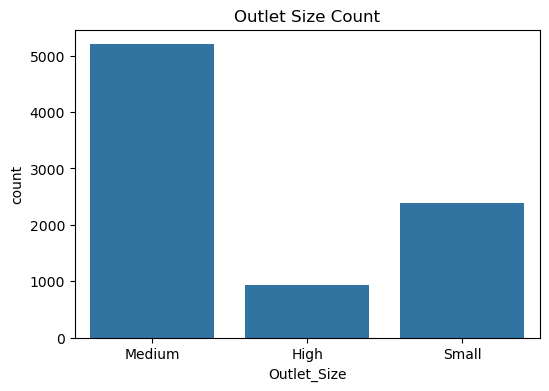

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Outlet_Size",data=bs_data)
plt.title("Outlet Size Count")
plt.show()

## Observation
- Medium outlet size appears most frequently in the dataset.
- Small outlet sizes are comparatively fewer.

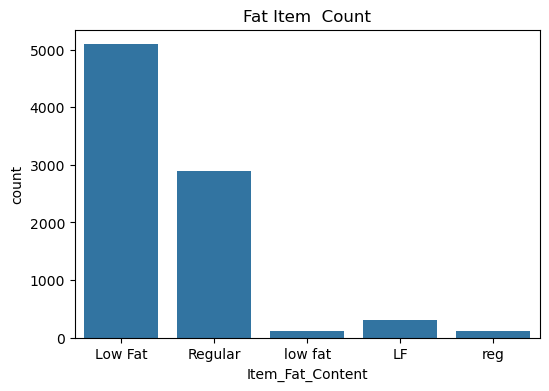

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='Item_Fat_Content', data=bs_data)
plt.title('Fat Item  Count')
plt.show()

## Observation
- Low Fat products are more common than Regular products.
- This indicates customer preference toward low-fat items.

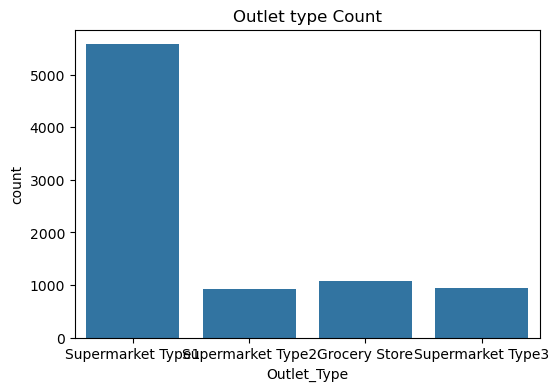

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outlet_Type', data=bs_data)
plt.title('Outlet type Count')
plt.show()

## Observation
- Supermarket Type1 has the highest number of outlets.
- Grocery stores are less common in the dataset.

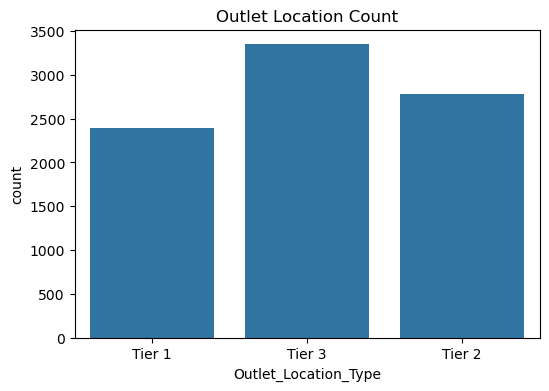

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outlet_Location_Type', data=bs_data)
plt.title('Outlet Location Count')
plt.show()

## Observation
- Tier 3 locations have the highest outlet count.
- This suggests stronger retail presence in Tier 3 cities.

# Target Value Analysis

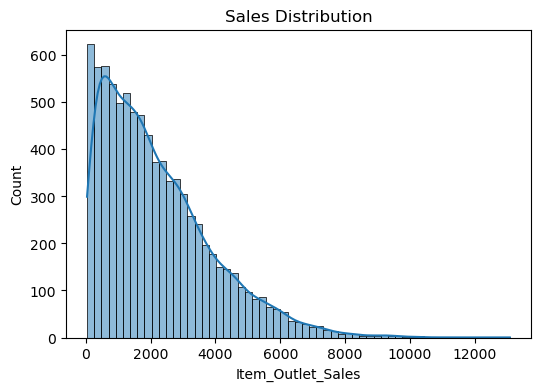

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(bs_data["Item_Outlet_Sales"],kde=True)
plt.title("Sales Distribution")
plt.show()

## Observation
- Item_Outlet_Sales is slightly right-skewed.
- Most products generate moderate sales while few products achieve very high sales.

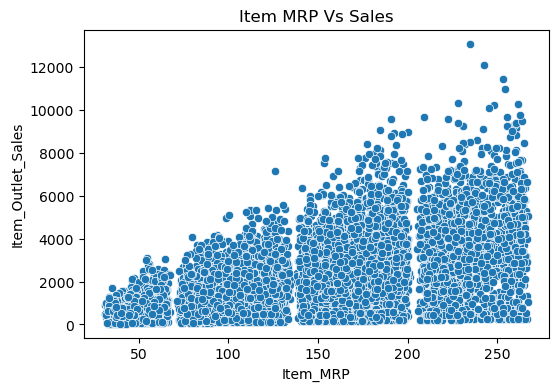

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Item_MRP",y="Item_Outlet_Sales",data=bs_data)
plt.title("Item MRP Vs Sales")
plt.show()

## Observation
- A positive relationship exists between Item_MRP and Item_Outlet_Sales.
- Products with higher MRP tend to generate higher sales.

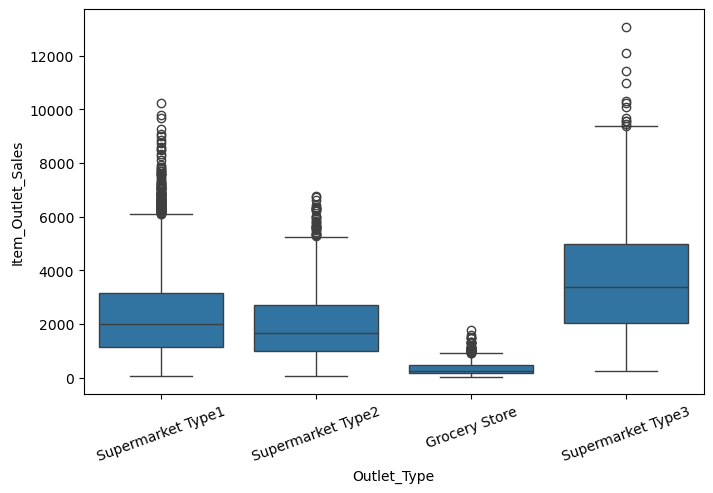

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Outlet_Type",y="Item_Outlet_Sales",data=bs_data)
plt.xticks(rotation=20)
plt.show()

## Observation
- Supermarket outlets generate higher sales compared to grocery stores.
- Sales variation differs significantly across outlet types.

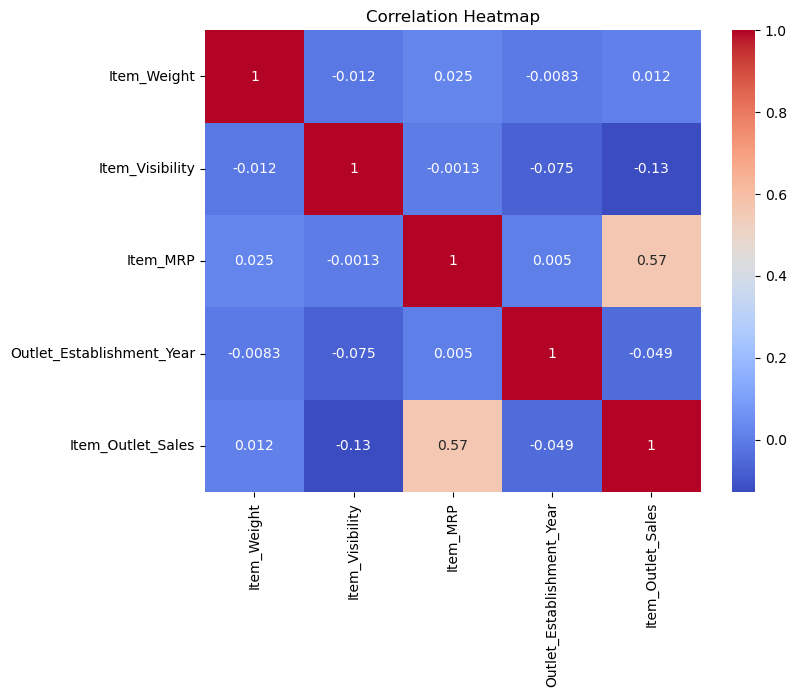

In [28]:
corr = bs_data.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Observation
- Item_MRP shows the strongest positive correlation with Item_Outlet_Sales.
- Other numerical variables have weak correlations with sales.

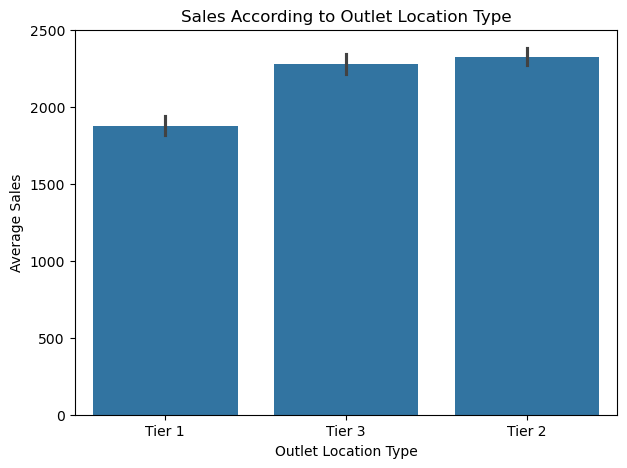

In [39]:
plt.figure(figsize=(7,5))
sns.barplot(x="Outlet_Location_Type",
            y="Item_Outlet_Sales",
            data=bs_data)

plt.title("Sales According to Outlet Location Type")
plt.xlabel("Outlet Location Type")
plt.ylabel("Average Sales")
plt.show()

## Observation
- Tier 3 outlets show comparatively higher average sales.
- Outlet location plays an important role in sales performance.

# Conclusion

From the analysis, the following insights were observed:

- Item_MRP significantly impacts product sales.
- Supermarket outlets perform better than grocery stores.
- Tier 3 cities contribute higher sales.
- Low Fat products dominate the dataset.
- Proper handling of missing values improved dataset quality.

Overall, outlet characteristics and product pricing are major factors influencing sales.